In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler

# Añadir la raíz del proyecto al path para importar el paquete src
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Importar las herramientas topológicas y de hostilidad
try:
    from src.Complexity_metrics_algorithm import compute_complexity_metrics
    from src.Hostility_measure_algorithm import hostility_measure
except ImportError:
    # Fallback por si el archivo fue nombrado HARS_algorithm.py directamente
    from src.Complexity_metrics_algorithm import compute_complexity_metrics
    from src.HARS_algorithm import hostility_measure

import warnings
warnings.filterwarnings('ignore')

print("Módulos cargados correctamente. Entorno listo para la experimentación topológica.")

Módulos cargados correctamente. Entorno listo para la experimentación topológica.


In [2]:
# Generar dataset sintético altamente desbalanceado
X, y = make_classification(
    n_samples=1500, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    weights=[0.95, 0.05], 
    class_sep=0.9, 
    random_state=42
)

classes, counts = np.unique(y, return_counts=True)
min_class = classes[np.argmin(counts)]
maj_class = classes[np.argmax(counts)]

n_min = counts[np.argmin(counts)]
n_maj = counts[np.argmax(counts)]
ratio_original = n_min / n_maj

print(f"Ratio Original del Dataset: {ratio_original:.3f}")

Ratio Original del Dataset: 0.056


In [5]:
def extraer_escalar(valor):
    """
    Fuerza la extracción de un valor escalar (float puro).
    Protege contra funciones que devuelven DataFrames, Series o Arrays de 1 elemento.
    """
    try:
        if isinstance(valor, (pd.DataFrame, pd.Series)):
            # Extraer el primer elemento si es Pandas
            return float(np.squeeze(valor.values))
        elif isinstance(valor, np.ndarray):
            # Extraer si es un array de numpy
            return float(valor.item())
        return float(valor)
    except Exception:
        return 0.0

def rastrear_evolucion(X, y, sampler_class, step=0.05):
    """
    Rastrea la evolución de las métricas de complejidad y hostilidad
    a medida que aumenta el ratio de sobremuestreo.
    """
    ratios = np.arange(ratio_original + step, 1.05, step)
    ratios = [r for r in ratios if r <= 1.0]
    if 1.0 not in ratios:
        ratios.append(1.0)
        
    historial = []
    
    # Asegurarnos de que los datos base son arrays de numpy (evita arrastrar índices de Pandas)
    X_arr = np.array(X)
    y_arr = np.array(y)
    
    # Evaluar el estado original (sin muestreo)
    met_min_orig = compute_complexity_metrics(X_arr, y_arr, target_class=min_class)
    met_maj_orig = compute_complexity_metrics(X_arr, y_arr, target_class=maj_class)
    
    # Manejar el desempaquetado de Hostilidad (Lancho)
    h_min_orig, h_maj_orig, _, _ = hostility_measure(X_arr, y_arr)
    
    historial.append({
        'Ratio': extraer_escalar(ratio_original),
        'dwCM9_Min': extraer_escalar(met_min_orig['dwCM9']),
        'dwCM9_Maj': extraer_escalar(met_maj_orig['dwCM9']),
        'Hostilidad_Min': extraer_escalar(h_min_orig),
        'Hostilidad_Maj': extraer_escalar(h_maj_orig)
    })
    
    # Bucle de sobremuestreo iterativo
    for r in ratios:
        try:
            sampler = sampler_class(sampling_strategy=r, random_state=42)
            X_res, y_res = sampler.fit_resample(X_arr, y_arr)
            
            # Forzar a numpy array post-muestreo
            X_res = np.array(X_res)
            y_res = np.array(y_res)
            
            # Métricas de Complejidad (Barella)
            met_min = compute_complexity_metrics(X_res, y_res, target_class=min_class)
            met_maj = compute_complexity_metrics(X_res, y_res, target_class=maj_class)
            
            # Métricas de Hostilidad (Lancho)
            h_min, h_maj, _, _ = hostility_measure(X_res, y_res)
            
            historial.append({
                'Ratio': extraer_escalar(r),
                'dwCM9_Min': extraer_escalar(met_min['dwCM9']),
                'dwCM9_Maj': extraer_escalar(met_maj['dwCM9']),
                'Hostilidad_Min': extraer_escalar(h_min),
                'Hostilidad_Maj': extraer_escalar(h_maj)
            })
        except Exception as e:
            # Ignorar de forma segura si el sampler falla por falta de vecinos
            pass 
            
    return pd.DataFrame(historial)

# Ejecutar el rastreo para los 3 métodos principales de sobremuestreo
print("Calculando evolución topológica para SMOTE...")
df_smote = rastrear_evolucion(X, y, SMOTE)

print("Calculando evolución topológica para ADASYN...")
df_adasyn = rastrear_evolucion(X, y, ADASYN)

print("Calculando evolución topológica para Random OverSampler (ROS)...")
df_ros = rastrear_evolucion(X, y, RandomOverSampler)

print("Cálculos finalizados. Proceda a ejecutar la Celda 4 para la visualización.")

Calculando evolución topológica para SMOTE...
Calculando evolución topológica para ADASYN...
Calculando evolución topológica para Random OverSampler (ROS)...
Cálculos finalizados. Proceda a ejecutar la Celda 4 para la visualización.


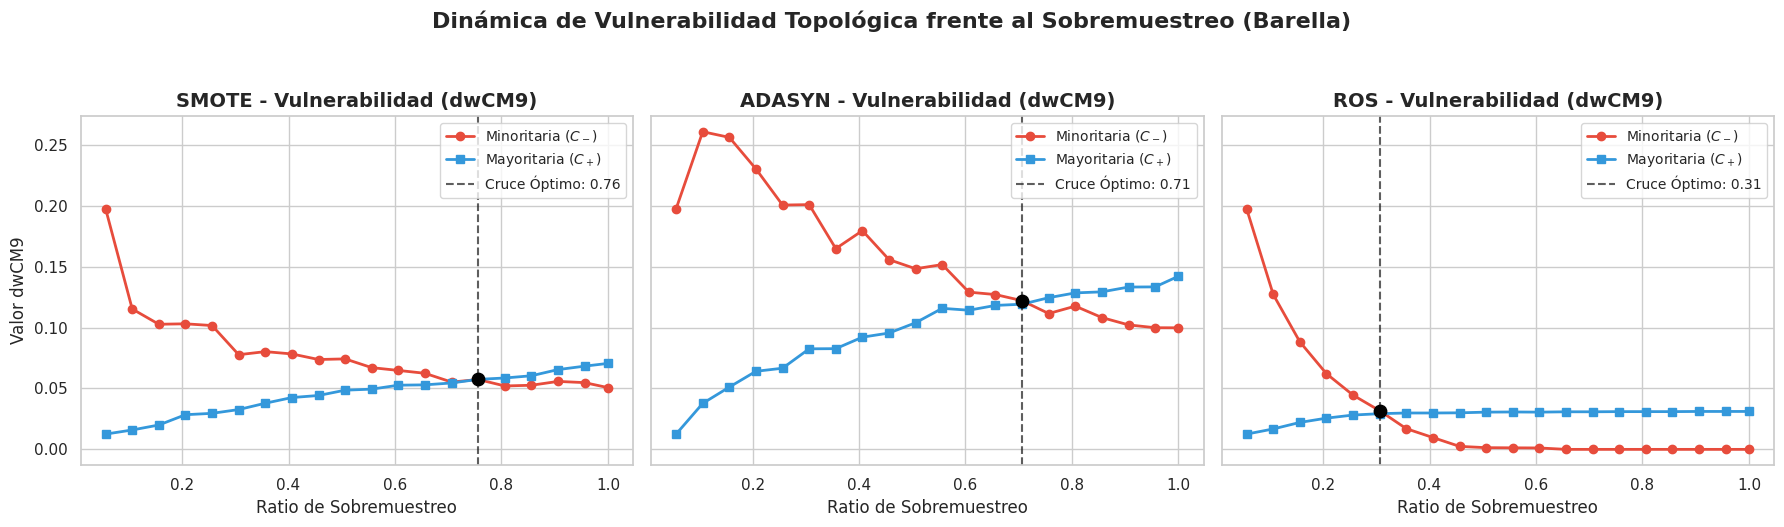

In [7]:
# Celda 4: Visualización Exclusiva de Complejidad (Barella - dwCM9)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets_graficos = [
    ('SMOTE', df_smote),
    ('ADASYN', df_adasyn),
    ('ROS', df_ros)
]

for i, (nombre, df) in enumerate(datasets_graficos):
    ax = axes[i]
    # Trazar curvas de vulnerabilidad
    ax.plot(df['Ratio'], df['dwCM9_Min'], marker='o', color='#e74c3c', linewidth=2, label='Minoritaria ($C_-$)')
    ax.plot(df['Ratio'], df['dwCM9_Maj'], marker='s', color='#3498db', linewidth=2, label='Mayoritaria ($C_+$)')
    
    # Encontrar y marcar el punto de intersección (Equilibrio Topológico)
    diff = np.abs(df['dwCM9_Min'] - df['dwCM9_Maj'])
    idx_opt = diff.idxmin()
    ratio_opt = df.loc[idx_opt, 'Ratio']
    
    ax.axvline(x=ratio_opt, color='k', linestyle='--', alpha=0.7, 
               label=f'Cruce Óptimo: {ratio_opt:.2f}')
    ax.scatter(ratio_opt, df.loc[idx_opt, 'dwCM9_Min'], color='black', s=80, zorder=5)
    
    ax.set_title(f'{nombre} - Vulnerabilidad (dwCM9)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio de Sobremuestreo', fontsize=12)
    if i == 0:
        ax.set_ylabel('Valor dwCM9', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)

plt.suptitle('Dinámica de Vulnerabilidad Topológica frente al Sobremuestreo (Barella)', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

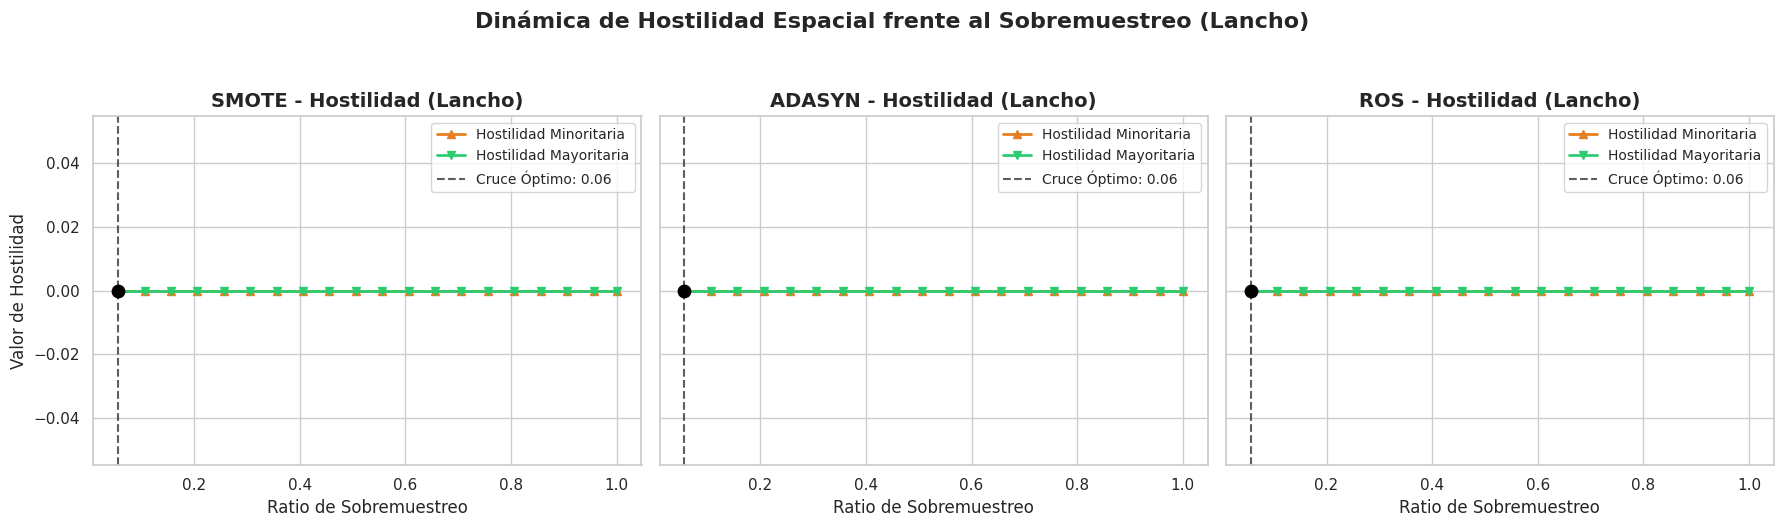

In [8]:
# Celda 5: Visualización Exclusiva de Hostilidad (Lancho)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (nombre, df) in enumerate(datasets_graficos):
    ax = axes[i]
    # Trazar curvas de hostilidad
    ax.plot(df['Ratio'], df['Hostilidad_Min'], marker='^', color='#e67e22', linewidth=2, label='Hostilidad Minoritaria')
    ax.plot(df['Ratio'], df['Hostilidad_Maj'], marker='v', color='#2ecc71', linewidth=2, label='Hostilidad Mayoritaria')
    
    # Encontrar y marcar el punto de intersección (Equilibrio de Hostilidad)
    diff = np.abs(df['Hostilidad_Min'] - df['Hostilidad_Maj'])
    idx_opt = diff.idxmin()
    ratio_opt = df.loc[idx_opt, 'Ratio']
    
    ax.axvline(x=ratio_opt, color='k', linestyle='--', alpha=0.7, 
               label=f'Cruce Óptimo: {ratio_opt:.2f}')
    ax.scatter(ratio_opt, df.loc[idx_opt, 'Hostilidad_Min'], color='black', s=80, zorder=5)
    
    ax.set_title(f'{nombre} - Hostilidad (Lancho)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio de Sobremuestreo', fontsize=12)
    if i == 0:
        ax.set_ylabel('Valor de Hostilidad', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)

plt.suptitle('Dinámica de Hostilidad Espacial frente al Sobremuestreo (Lancho)', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()